# TinyStories — word-frequency analysis

Streams `TinyStories-train.txt` (or the preprocessed `-oneline` sibling if present), applies the same `normalize_text` the dataloader uses, and counts words.

Sections:
1. Stream + count
2. Summary stats (total tokens, vocab size, type/token ratio)
3. Top-N most frequent words
4. Cumulative coverage by rank
5. Zipf plot
6. The rare tail (hapax legomena, etc.)

In [15]:
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

# Make the project root importable so we can pull `normalize_text`.
HERE = Path.cwd().resolve()
for cand in (HERE, HERE.parent, HERE.parent.parent):
    if (cand / 'modelling' / 'tinystories.py').exists():
        sys.path.insert(0, str(cand))
        ROOT = cand
        break
else:
    raise RuntimeError('could not locate project root containing modelling/tinystories.py')

# Reload so we always pick up the latest normalize_text — matters when the
# source file changed mid-session (no kernel restart needed).
import importlib
import modelling.tinystories
importlib.reload(modelling.tinystories)
from modelling.tinystories import normalize_text

# Smoke-check: apostrophes should now fuse, not split into "ben s" / "didn t".
for s in ["Ben's dog", "didn't", "rock 'n' roll"]:
    print(f'  {s!r:25} -> {normalize_text(s)!r}')

DATA_DIR = ROOT / 'modelling' / 'data'
ONELINE = DATA_DIR / 'TinyStories-train-oneline.txt'
RAW = DATA_DIR / 'TinyStories-train.txt'
SOURCE = ONELINE if ONELINE.exists() else RAW

print(f'\nreading from: {SOURCE.name}')
print(f'size:         {SOURCE.stat().st_size / 1024**3:.2f} GB')

  "Ben's dog"               -> 'bens dog'
  "didn't"                  -> 'didnt'
  "rock 'n' roll"           -> 'rock n roll'

reading from: TinyStories-train-oneline.txt
size:         1.76 GB


## 1. Stream + count

Set `MAX_LINES` to an int for a fast first pass; `None` reads the whole file.
Whole-train scan is roughly 2–5 minutes.

In [2]:
MAX_LINES = None        # e.g. 200_000 for a fast test pass
PROGRESS_EVERY = 500_000
DELIMITER = '<|endoftext|>'  # raw-file story separator; skip so it doesn't pollute counts

counts: Counter[str] = Counter()
total_tokens = 0
total_chars = 0
lines_read = 0

t0 = time.time()
with SOURCE.open('r', encoding='utf-8') as f:
    for i, raw in enumerate(f, 1):
        if MAX_LINES is not None and i > MAX_LINES:
            break
        if raw.strip() == DELIMITER:
            continue
        text = normalize_text(raw)
        if not text:
            continue
        words = text.split()
        counts.update(words)
        total_tokens += len(words)
        total_chars += len(text)
        if i % PROGRESS_EVERY == 0:
            elapsed = time.time() - t0
            print(f'  {i:>12,} lines | {total_tokens:>12,} tokens | {len(counts):>9,} types | {elapsed:5.1f}s')
        lines_read = i

elapsed = time.time() - t0
print(f'\ndone in {elapsed:.1f}s — {lines_read:,} lines, {total_tokens:,} tokens, {len(counts):,} unique types')

       500,000 lines |   88,082,380 tokens |    29,577 types |  35.1s
     1,000,000 lines |  176,039,024 tokens |    36,975 types |  69.6s
     1,500,000 lines |  263,246,349 tokens |    42,272 types | 103.7s
     2,000,000 lines |  350,549,911 tokens |    46,342 types | 137.3s

done in 145.8s — 2,119,489 lines, 371,707,446 tokens, 47,127 unique types


## 2. Summary stats

In [3]:
vocab_size = len(counts)
ttr = vocab_size / total_tokens if total_tokens else 0.0
avg_word_len = total_chars / total_tokens if total_tokens else 0.0
singletons = sum(1 for c in counts.values() if c == 1)

print(f'total tokens:          {total_tokens:>12,}')
print(f'unique types (vocab):  {vocab_size:>12,}')
print(f'type/token ratio:      {ttr:>12.5f}')
print(f'avg word length:       {avg_word_len:>12.2f} chars')
print(f'singletons (count==1): {singletons:>12,}  ({100*singletons/vocab_size:.1f}% of vocab)')
print(f'total chars (norm.):   {total_chars:>12,}')

total tokens:           371,707,446
unique types (vocab):        47,127
type/token ratio:           0.00013
avg word length:               4.88 chars
singletons (count==1):       11,184  (23.7% of vocab)
total chars (norm.):   1,813,690,013


## 3. Top words

In [4]:
TOP_N = 50

top = counts.most_common(TOP_N)
width = max(len(w) for w, _ in top)
print(f'{"rank":>4}  {"word":<{width}}  {"count":>12}  {"%":>6}  {"cum %":>6}')
print('-' * (4 + 2 + width + 2 + 12 + 2 + 6 + 2 + 6))
running = 0
for r, (w, c) in enumerate(top, 1):
    running += c
    pct = 100 * c / total_tokens
    cum = 100 * running / total_tokens
    print(f'{r:>4}  {w:<{width}}  {c:>12,}  {pct:>5.2f}%  {cum:>5.2f}%')

rank  word           count       %   cum %
------------------------------------------
   1  the       20,241,746   5.45%   5.45%
   2  and       18,119,105   4.87%  10.32%
   3  to        12,648,861   3.40%  13.72%
   4  a         11,477,848   3.09%  16.81%
   5  was        9,436,739   2.54%  19.35%
   6  he         7,956,508   2.14%  21.49%
   7  she        7,699,906   2.07%  23.56%
   8  they       6,755,364   1.82%  25.38%
   9  it         6,687,978   1.80%  27.18%
  10  her        4,922,066   1.32%  28.50%
  11  said       3,596,556   0.97%  29.47%
  12  in         3,221,613   0.87%  30.34%
  13  you        3,214,671   0.86%  31.20%
  14  his        3,162,439   0.85%  32.05%
  15  with       3,105,779   0.84%  32.89%
  16  lily       2,842,226   0.76%  33.65%
  17  that       2,774,352   0.75%  34.40%
  18  so         2,719,058   0.73%  35.13%
  19  of         2,679,213   0.72%  35.85%
  20  day        2,670,513   0.72%  36.57%
  21  but        2,567,143   0.69%  37.26%
  22  had  

## 4. Cumulative coverage by rank

How many of the most frequent types do you need to cover X% of all tokens?

In [5]:
ranked = sorted(counts.values(), reverse=True)
running = 0
next_target_idx = 0
targets = [0.50, 0.80, 0.90, 0.95, 0.99, 0.999]
thresholds = [int(t * total_tokens) for t in targets]
results = []
for rank, c in enumerate(ranked, 1):
    running += c
    while next_target_idx < len(targets) and running >= thresholds[next_target_idx]:
        results.append((targets[next_target_idx], rank, 100 * rank / vocab_size))
        next_target_idx += 1

print(f'{"coverage":>10}  {"# types":>10}  {"% of vocab":>12}')
for tgt, rank, pct_vocab in results:
    print(f'{100*tgt:>9.1f}%  {rank:>10,}  {pct_vocab:>11.2f}%')

  coverage     # types    % of vocab
     50.0%          51         0.11%
     80.0%         371         0.79%
     90.0%         916         1.94%
     95.0%       1,806         3.83%
     99.0%       4,146         8.80%
     99.9%      10,823        22.97%


## 5. Zipf plot

Log-rank vs log-frequency. A pure Zipf distribution has slope −1.

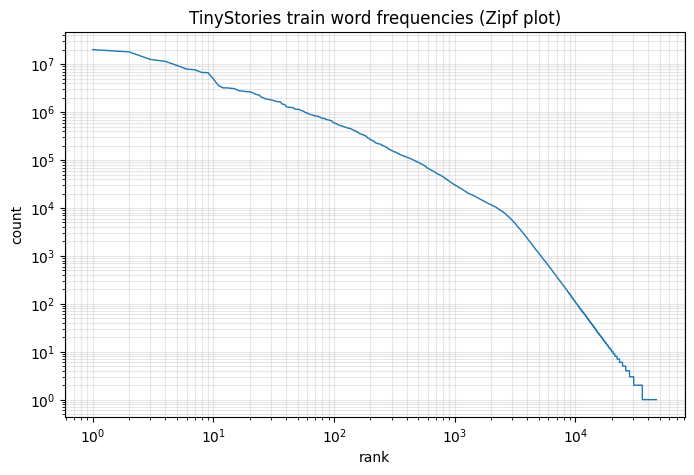

In [6]:
ranks = range(1, len(ranked) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(list(ranks), ranked, linewidth=1)
ax.set_xlabel('rank')
ax.set_ylabel('count')
ax.set_title('TinyStories train word frequencies (Zipf plot)')
ax.grid(True, which='both', alpha=0.3)
plt.show()

## 6. The rare tail

Distribution of types by count, plus a sample of words that appear exactly once.
Many of these will be tokenization artefacts (concatenations across removed punctuation, OCR noise, etc.) — useful for sanity-checking the normalizer.

In [7]:
buckets = [(1, 1), (2, 2), (3, 5), (6, 10), (11, 100), (101, 1_000), (1_001, 10_000), (10_001, 10**12)]
print(f'{"count range":>16}  {"# types":>10}  {"% vocab":>9}  {"# tokens":>14}  {"% tokens":>9}')
for lo, hi in buckets:
    types_in = [c for c in counts.values() if lo <= c <= hi]
    n_types = len(types_in)
    n_tokens = sum(types_in)
    label = f'{lo:,}' if lo == hi else f'{lo:,}–{hi:,}' if hi < 10**11 else f'{lo:,}+'
    print(f'{label:>16}  {n_types:>10,}  {100*n_types/vocab_size:>8.2f}%  {n_tokens:>14,}  {100*n_tokens/total_tokens:>8.3f}%')

     count range     # types    % vocab        # tokens   % tokens
               1      11,184     23.73%          11,184     0.003%
               2       5,464     11.59%          10,928     0.003%
             3–5       5,841     12.39%          22,592     0.006%
            6–10       4,691      9.95%          35,735     0.010%
          11–100       9,692     20.57%         343,194     0.092%
       101–1,000       5,067     10.75%       1,781,679     0.479%
    1,001–10,000       2,942      6.24%      11,270,038     3.032%
         10,001+       2,246      4.77%     358,232,096    96.375%


In [8]:
import random
random.seed(0)
hapax = [w for w, c in counts.items() if c == 1]
print(f'{len(hapax):,} hapax legomena. Random sample of 30:')
for w in random.sample(hapax, min(30, len(hapax))):
    print(f'  {w}')

11,184 hapax legomena. Random sample of 30:
  lessonanne
  splashiest
  astride
  cobalt
  lovingkindness
  analyse
  fryer
  payphone
  schoolgirl
  obiediently
  clumby
  zqx
  feeing
  refrain
  unlooed
  eally
  operators
  jellied
  phy
  herall
  heartsick
  spalsh
  favourte
  startd
  marketgoers
  daytons
  girleven
  butterflybut
  ammas
  broter


## 7. Sentence coverage by vocab cap

If we split the corpus into sentences (cut at `.`) and only keep sentences whose words are *all* in the top-N most frequent words, how many sentences do we have?

The dataloader's `normalize_text` strips all punctuation, so we have to split on `.` *before* normalizing. We treat `!` and `?` as sentence terminators too — easy to drop them from `_TERMINATOR_RE` if you want strictly only `.`.

Approach: a second pass over the file. For each sentence we record one int — the max rank of any word it contains. Then "is this sentence covered by top-N?" is just `max_rank <= N`.
"help" vs "helping" stay as separate words; capitalization and punctuation are already collapsed by `normalize_text`.

In [9]:
import re
import numpy as np

# Build a word -> rank table (rank 1 = most frequent).
rank_of: dict[str, int] = {w: r for r, (w, _) in enumerate(counts.most_common(), start=1)}

# Sentence-terminator regex. Drop `!?` here for strictly-period splits.
_TERMINATOR_RE = re.compile(r'[.!?]+')

sentence_max_rank: list[int] = []
sentence_lens: list[int] = []
empty_sentences = 0

t0 = time.time()
with SOURCE.open('r', encoding='utf-8') as f:
    for i, raw in enumerate(f, 1):
        if MAX_LINES is not None and i > MAX_LINES:
            break
        if raw.strip() == DELIMITER:
            continue
        for piece in _TERMINATOR_RE.split(raw):
            text = normalize_text(piece)
            if not text:
                empty_sentences += 1
                continue
            words = text.split()
            sentence_max_rank.append(max(rank_of[w] for w in words))
            sentence_lens.append(len(words))
        if i % PROGRESS_EVERY == 0:
            elapsed = time.time() - t0
            print(f'  {i:>12,} lines | {len(sentence_max_rank):>12,} sentences | {elapsed:5.1f}s')

mx = np.asarray(sentence_max_rank, dtype=np.int32)
ln = np.asarray(sentence_lens, dtype=np.int32)
elapsed = time.time() - t0
print(f'\ndone in {elapsed:.1f}s — {len(mx):,} sentences ({empty_sentences:,} empty pieces skipped)')
print(f'avg sentence length: {ln.mean():.2f} words; total tokens in sentences: {ln.sum():,}')

       500,000 lines |    9,766,325 sentences |  55.4s
     1,000,000 lines |   19,505,124 sentences | 111.9s
     1,500,000 lines |   29,104,210 sentences | 166.1s
     2,000,000 lines |   38,693,459 sentences | 218.9s

done in 234.3s — 41,048,266 sentences (2,147,700 empty pieces skipped)
avg sentence length: 9.06 words; total tokens in sentences: 371,707,446


In [10]:
# Coverage table: for each vocab cap, how many sentences are *fully* in the top-N?
caps = [50, 100, 200, 500, 1000, 2000, 5000, 10_000, 20_000, vocab_size]
total_sentences = len(mx)
total_tokens_sent = int(ln.sum())

print(f'{"vocab cap":>10}  {"# sentences":>14}  {"% sent":>7}  {"# tokens":>14}  {"% tokens":>9}  {"avg len":>8}')
print('-' * 70)
for cap in caps:
    if cap > vocab_size:
        continue
    mask = mx <= cap
    n_s = int(mask.sum())
    n_t = int(ln[mask].sum())
    avg = ln[mask].mean() if n_s else 0.0
    label = f'{cap:,}' if cap < vocab_size else f'{cap:,} (all)'
    print(f'{label:>10}  {n_s:>14,}  {100*n_s/total_sentences:>6.2f}%  {n_t:>14,}  {100*n_t/total_tokens_sent:>8.2f}%  {avg:>8.2f}')

 vocab cap     # sentences   % sent        # tokens   % tokens   avg len
----------------------------------------------------------------------
        50         370,272    0.90%       1,249,020      0.34%      3.37
       100       1,689,195    4.12%       8,713,555      2.34%      5.16
       200       4,323,287   10.53%      23,493,875      6.32%      5.43
       500      11,087,415   27.01%      72,404,281     19.48%      6.53
     1,000      19,288,826   46.99%     142,990,057     38.47%      7.41
     2,000      28,607,583   69.69%     235,005,854     63.22%      8.21
     5,000      38,854,742   94.66%     346,255,826     93.15%      8.91
    10,000      40,617,582   98.95%     366,532,728     98.61%      9.02
    20,000      40,971,018   99.81%     370,762,081     99.75%      9.05
47,127 (all)      41,048,266  100.00%     371,707,446    100.00%      9.06


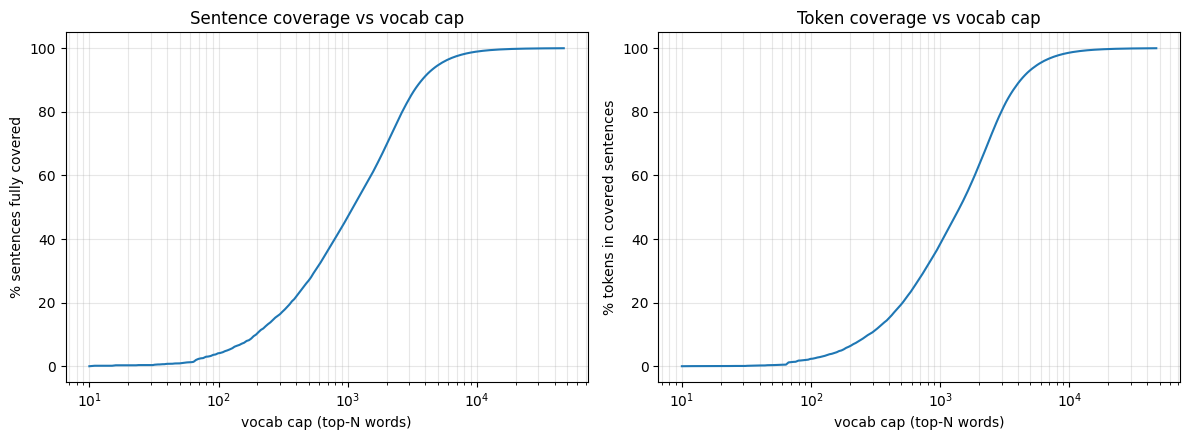

In [11]:
# Coverage curve over a log-spaced sweep of vocab caps.
sweep = np.unique(np.geomspace(10, vocab_size, 200).astype(np.int64))

# Sort once; for each cap, sentences with max_rank <= cap are the ones whose
# max_rank is in mx_sorted[:k] where k = searchsorted(cap). This avoids an
# O(N) scan per cap point.
mx_sorted = np.sort(mx)
ln_sorted_by_mx = ln[np.argsort(mx)]
cum_tokens = np.cumsum(ln_sorted_by_mx)
sent_covered = np.searchsorted(mx_sorted, sweep, side='right')
tok_covered = np.where(sent_covered > 0, cum_tokens[np.clip(sent_covered, 1, len(mx)) - 1], 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].semilogx(sweep, 100 * sent_covered / total_sentences)
ax[0].set_xlabel('vocab cap (top-N words)')
ax[0].set_ylabel('% sentences fully covered')
ax[0].set_title('Sentence coverage vs vocab cap')
ax[0].grid(True, which='both', alpha=0.3)

ax[1].semilogx(sweep, 100 * tok_covered / total_tokens_sent)
ax[1].set_xlabel('vocab cap (top-N words)')
ax[1].set_ylabel('% tokens in covered sentences')
ax[1].set_title('Token coverage vs vocab cap')
ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Inverse view: pick a target number of sentences and read off the smallest cap that hits it.
import bisect

mx_sorted_list = mx_sorted.tolist()  # bisect needs a list / sorted iterable

targets = [10_000, 50_000, 100_000, 250_000, 500_000, 1_000_000, 2_000_000, 5_000_000]
print(f'{"target #sentences":>20}  {"min vocab cap":>14}  {"actual #sentences":>20}  {"covered tokens":>15}')
for t in targets:
    if t > total_sentences:
        continue
    # smallest cap such that #covered >= t
    cap = mx_sorted_list[t - 1]
    n_s = int((mx <= cap).sum())
    n_t = int(ln[mx <= cap].sum())
    print(f'{t:>20,}  {cap:>14,}  {n_s:>20,}  {n_t:>15,}')

   target #sentences   min vocab cap     actual #sentences   covered tokens
              10,000              11                62,652          124,218
              50,000              11                62,652          124,218
             100,000              16               121,811          241,462
             250,000              37               263,436          724,599
             500,000              59               507,959        1,702,685
           1,000,000              72             1,008,188        5,020,342
           2,000,000             116             2,025,000       10,600,861
           5,000,000             226             5,010,512       28,019,401


In [13]:
# Inspect what a top-CAP vocab cut would look like. Streams the file again to
# pull example kept/rejected sentences but stops as soon as it has enough.
CAP = 500
N_KEEP = 10
N_REJECT = 10
SAMPLE_EVERY = 50_000  # spread examples across the corpus, not just the first 100 sentences

# 1. Show the top-CAP vocab itself.
top_list = [w for w, _ in counts.most_common(CAP)]
print(f'top-{CAP} vocab (first 50): {" ".join(top_list[:50])}')
print(f'top-{CAP} vocab (last 20):  {" ".join(top_list[-20:])}\n')

# 2. Sample some kept / rejected sentences.
kept, rejected = [], []
kept_seen = rej_seen = 0
sentences_scanned = 0

with SOURCE.open('r', encoding='utf-8') as f:
    for raw in f:
        if raw.strip() == DELIMITER:
            continue
        for piece in _TERMINATOR_RE.split(raw):
            text = normalize_text(piece)
            if not text:
                continue
            words = text.split()
            sentences_scanned += 1
            top_rank = max(rank_of[w] for w in words)
            if top_rank <= CAP:
                if kept_seen % SAMPLE_EVERY == 0 and len(kept) < N_KEEP:
                    kept.append(text)
                kept_seen += 1
            else:
                if rej_seen % SAMPLE_EVERY == 0 and len(rejected) < N_REJECT:
                    oov = [w for w in words if rank_of[w] > CAP]
                    rejected.append((text, oov))
                rej_seen += 1
        if len(kept) >= N_KEEP and len(rejected) >= N_REJECT:
            break

# 3. Print.
print(f'scanned {sentences_scanned:,} sentences\n')

print(f'== {N_KEEP} sample sentences KEPT (all words in top {CAP}) ==')
for s in kept:
    print(f'  • {s}')

print(f'\n== {N_REJECT} sample sentences REJECTED (OOV in [brackets]) ==')
for s, oov in rejected:
    oov_set = set(oov)
    annotated = ' '.join(f'[{w}]' if w in oov_set else w for w in s.split())
    print(f'  • {annotated}')

# 4. Recap of the math from the prior table.
n_words = int(ln[mx <= CAP].sum())
print(f'\nrecap: cap={CAP} → {(mx <= CAP).sum():,} sentences, '
    f'{n_words:,} words ≈ {int(n_words * (total_chars / total_tokens)):,} chars '
    f'({n_words * (total_chars / total_tokens) / 164e6:.1f}× SOTA token budget)')

top-500 vocab (first 50): the and to a was he she they it her said in you his with lily that so of day but had on mom one for there very little time i happy is not big saw were once play are wanted upon their him girl them be have can at
top-500 vocab (last 20):  someone frog everywhere arrived wonderful window rain well own table others colors swing wind broken able cream gone else read

scanned 1,702,329 sentences

== 10 sample sentences KEPT (all words in top 500) ==
  • do you want to play
  • timmy thought about it and realized lily was right
  • once upon a time there was a little bunny named benny
  • she lived in a small house with her mom and dad
  • he sees a girl with a red ball
  • once upon a time there was a little girl named lily
  • i played with him
  • tom said
  • ok ben says
  • i heard that you know where to find it said the bear

== 10 sample sentences REJECTED (OOV in [brackets]) ==
  • one day a little girl named lily found a [needle] in her room
  • it [might] 

## 8. Export the vocab

Write the top-`CAP` words (one per line, ordered by frequency) to `data/tinystories_vocab_top{CAP}.txt`. This file is what the dataset-filter step will read to decide which sentences to keep.

In [14]:
# Export the top-CAP vocab as one-word-per-line, ordered by frequency.
out_path = DATA_DIR / f'tinystories_vocab_top{CAP}.txt'
top_words = [w for w, _ in counts.most_common(CAP)]

with out_path.open('w', encoding='utf-8') as f:
    for w in top_words:
        f.write(w + '\n')

print(f'wrote {len(top_words):,} words to {out_path}')
print(f'first 10: {top_words[:10]}')
print(f'last  10: {top_words[-10:]}')

wrote 500 words to /Users/matt/Library/CloudStorage/OneDrive-Personal/Code/LLM/BitNet6502/modelling/data/tinystories_vocab_top500.txt
first 10: ['the', 'and', 'to', 'a', 'was', 'he', 'she', 'they', 'it', 'her']
last  10: ['others', 'colors', 'swing', 'wind', 'broken', 'able', 'cream', 'gone', 'else', 'read']
